In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="6"

In [3]:
import torch
import numpy as np

In [4]:
from IPython.display import Image as IPyImage
from IPython.display import display
from PIL import Image

In [5]:
from open_vocab_mot import DUKEMTMC_VIDEO_REID_PATH, DUKEMTMC_VIDEO_REID_SIDECAR_PATH

In [6]:
from open_vocab_mot.data import DukeMTMCVideoDataset, DukeSplit, collate_duke_mtmc_video_ds, DukeMTMCItemBatch

In [7]:
duke_ds = DukeMTMCVideoDataset(DUKEMTMC_VIDEO_REID_PATH, DukeSplit.TRAIN, load_image=True, verbose=True)

Loading split TRAIN: 369656it [00:00, 432966.64it/s]
Loading split QUERY: 111848it [00:00, 275699.52it/s]
Loading split GALLERY: 445764it [00:01, 381324.94it/s]


In [8]:
len(duke_ds)

369656

In [9]:
sample = duke_ds[9003]

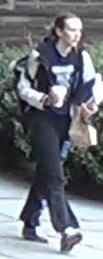

In [10]:
display(sample.frame)

In [11]:
print(sample.frame_path)

/z/dat/DukeMTMC-VideoReID/train/2432/1559/2432_C3_F0052_X44157.jpg


In [12]:
from aidan_lib.models.sam3_batched_img import SAM3BatchedImageHarness

/scratch4/home/adempst/projects/open_vocab_mot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch4/home/adempst/projects/open_vocab_mot/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [13]:
sam_harness = SAM3BatchedImageHarness()

Building SAM3 image model with torch.bfloat16 precision
Built model, now moving to device cuda with torch.bfloat16 precision
Finished loading model


In [14]:
from torch.utils.data import DataLoader

In [15]:
loader = DataLoader(duke_ds, batch_size=2, collate_fn=collate_duke_mtmc_video_ds)

In [16]:
batch = next(iter(loader))

In [17]:
import torchvision.transforms.functional as TF
tensor_image_batch = []
for img in batch.frames:
    tensor_image_batch.append(
        TF.to_tensor(img).cuda()
    )

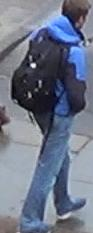

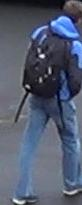

In [18]:
display(TF.to_pil_image(tensor_image_batch[0]))
display(batch.frames[1])

In [19]:
out = sam_harness([batch.frames[0], batch.frames[1]], "Person", move_to_cpu=False)

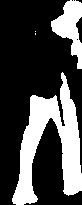

In [20]:
display(Image.fromarray(out[1].masks[0].cpu().numpy()))

In [21]:
from aidan_lib.models.dino_lib import DINOv3Harness

In [22]:
dino_harness = DINOv3Harness(checkpoint="facebook/dinov3-vitl16-pretrain-lvd1689m", max_side_len=1024)

Loading weights: 100%|██████████| 415/415 [00:00<00:00, 11036.87it/s]


In [23]:
sam_output = sam_harness(tensor_image_batch, "Person", move_to_cpu=False)

In [24]:
major_masks = []
for frame_out in sam_output:
    major_mask_idx = torch.argmax(frame_out.masks.sum((1, 2)))
    print(major_mask_idx)
    major_masks.append(frame_out.masks[major_mask_idx])

tensor(1, device='cuda:0')
tensor(0, device='cuda:0')


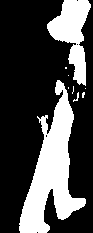

In [25]:
display(Image.fromarray(major_masks[0].cpu().numpy()))

In [26]:
print(len(tensor_image_batch))
print(tensor_image_batch[0].shape)
print(len(major_masks))
print(major_masks[0].shape)

2
torch.Size([3, 233, 93])
2
torch.Size([233, 93])


In [27]:
dino_out = dino_harness.match_bool_segmentations_to_dino(tensor_image_batch, major_masks)

In [28]:
# from tqdm import tqdm
# import time
# from torchvision.utils import save_image
# import awkward as ak

# loader = DataLoader(duke_ds, batch_size=8, collate_fn=collate_duke_mtmc_video_ds, shuffle=False)

# time_converting_to_tensor = 0
# time_in_sam = 0
# time_finding_best_mask = 0
# time_in_dino = 0
# time_saving = 0

# already_seen_paths = set()
# current_parent_path = None
# file_dino_embeddings = {}  # Maps from file path to numpy array of embeddings
# for batch in tqdm(loader):
#     assert isinstance(batch, DukeMTMCItemBatch)
#     tensor_image_batch = []
#     start_time = time.perf_counter()
#     for img in batch.frames:
#         tensor_image_batch.append(
#             TF.to_tensor(img).cuda()
#         )
#     time_converting_to_tensor += time.perf_counter() - start_time
    
#     start_time = time.perf_counter()
#     sam_output = sam_harness(tensor_image_batch, "Person", move_to_cpu=False)
#     # sam_output = sam_harness(batch.frames, "Person", move_to_cpu=False)
#     time_in_sam += time.perf_counter() - start_time

#     start_time = time.perf_counter()
#     major_masks = []
#     for frame_out in sam_output:
#         major_mask_idx = torch.argmax(frame_out.masks.sum((1, 2)))
#         major_masks.append(frame_out.masks[major_mask_idx])
#     time_finding_best_mask += time.perf_counter() - start_time

#     start_time = time.perf_counter()
#     dino_out = dino_harness.match_bool_segmentations_to_dino(tensor_image_batch, major_masks)
#     # dino_out = dino_harness.match_bool_segmentations_to_dino(batch.frames, major_masks)
#     time_in_dino += time.perf_counter() - start_time

#     start_time = time.perf_counter()
#     for idx in range(len(batch.frame_paths)):
#         frame_path = batch.frame_paths[idx]
#         parent_path = frame_path.parent
#         frame_stem = frame_path.stem
#         major_mask = major_masks[idx]
#         dino_embedding = dino_out[idx][0]

#         if parent_path != current_parent_path:
#             print(f"Swapping to new parent path {parent_path}")
#             if parent_path in already_seen_paths:
#                 print(f"WARNING: Going back to old parent!")
            
#             if current_parent_path is None:
#                 # Then this is the first parent we are entering now. Just skip this one
#                 print(f"Starting first actual parent")
#                 current_parent_path = parent_path
#                 already_seen_paths.add(parent_path)
#             else:
#                 # Reformat array to dataset format
#                 print("Reformatting to awkward", flush=True)
#                 file_stems = []
#                 embeddings_list = []
#                 bboxs_list = []
#                 overlaps_list = []
#                 for file_stem, embedding_data in file_dino_embeddings.items():
#                     file_stems.append(file_stem)
#                     embeddings_list.append(embedding_data["embeddings"])
#                     bboxs_list.append(embedding_data["bboxs"])
#                     overlaps_list.append(embedding_data["overlaps"])
                
#                 print("Constructing awkward dataset", flush=True)
#                 dataset = ak.Array({
#                     "file_stems": file_stems,
#                     "embeddings_list": embeddings_list,
#                     "bboxs_list": bboxs_list,
#                     "overlaps_list": overlaps_list
#                 })
#                 parent_rel_path = parent_path.relative_to(DUKEMTMC_VIDEO_REID_PATH)
#                 sidecar_parent_path = DUKEMTMC_VIDEO_REID_SIDECAR_PATH / parent_rel_path
#                 embeddings_data_path = sidecar_parent_path / "embeddings_data.parquet"
#                 print("Saving dataset parquet")
#                 ak.to_parquet(dataset, embeddings_data_path)
#                 print("Done saving dataset parquet")

#                 file_dino_embeddings = {}
#                 current_parent_path = parent_path
#                 already_seen_paths.add(parent_path)

#         file_dino_embeddings[frame_stem] = {
#             "embeddings": dino_embedding.dino_embeddings.cpu().numpy(),
#             "bboxs": dino_embedding.dino_bboxes.cpu().numpy(),
#             "overlaps": dino_embedding.dino_overlaps.cpu().numpy()
#         }

#         # Get the path in the sidecar dir
#         parent_rel_path = parent_path.relative_to(DUKEMTMC_VIDEO_REID_PATH)
#         sidecar_parent_path = DUKEMTMC_VIDEO_REID_SIDECAR_PATH / parent_rel_path
#         # Ensure our parent directory exists
#         sidecar_parent_path.mkdir(parents=True, exist_ok=True)

#         # Save the mask
#         sidecar_mask_path = sidecar_parent_path / f"{frame_stem}_major_mask.png"
#         # print(f"Saving mask to {sidecar_mask_path}")
#         float_mask = major_mask.float()
#         save_image(float_mask, sidecar_mask_path)
#     time_saving += time.perf_counter() - start_time
        

#     # print(batch.frame_paths)
#     # break

In [29]:
# print(time_converting_to_tensor)
# print(time_in_sam)
# print(time_finding_best_mask)
# print(time_in_dino)
# print(time_saving)

In [30]:
# print(time_converting_to_tensor)
# print(time_in_sam)
# print(time_finding_best_mask)
# print(time_in_dino)

In [ ]:
# from tqdm import tqdm
# import time
# from torchvision.utils import save_image
# import awkward as ak

# loader = DataLoader(duke_ds, batch_size=8, collate_fn=collate_duke_mtmc_video_ds, shuffle=False)

# time_converting_to_tensor = 0
# time_in_sam = 0
# time_finding_best_mask = 0
# time_saving = 0

# already_seen_paths = set()
# current_parent_path = None
# file_dino_embeddings = {}  # Maps from file path to numpy array of embeddings
# for batch in tqdm(loader):
#     assert isinstance(batch, DukeMTMCItemBatch)
#     tensor_image_batch = []
#     start_time = time.perf_counter()
#     for img in batch.frames:
#         tensor_image_batch.append(
#             TF.to_tensor(img).cuda()
#         )
#     time_converting_to_tensor += time.perf_counter() - start_time
    
#     start_time = time.perf_counter()
#     sam_output = sam_harness(tensor_image_batch, "Person", move_to_cpu=False)
#     # sam_output = sam_harness(batch.frames, "Person", move_to_cpu=False)
#     time_in_sam += time.perf_counter() - start_time

#     start_time = time.perf_counter()
#     major_masks = []
#     for frame_out in sam_output:
#         major_mask_idx = torch.argmax(frame_out.masks.sum((1, 2)))
#         major_masks.append(frame_out.masks[major_mask_idx])
#     time_finding_best_mask += time.perf_counter() - start_time

#     start_time = time.perf_counter()
#     for idx in range(len(batch.frame_paths)):
#         frame_path = batch.frame_paths[idx]
#         parent_path = frame_path.parent
#         frame_stem = frame_path.stem
#         major_mask = major_masks[idx]

#         # Get the path in the sidecar dir
#         parent_rel_path = parent_path.relative_to(DUKEMTMC_VIDEO_REID_PATH)
#         sidecar_parent_path = DUKEMTMC_VIDEO_REID_SIDECAR_PATH / parent_rel_path
#         # Ensure our parent directory exists
#         sidecar_parent_path.mkdir(parents=True, exist_ok=True)

#         # Save the mask
#         sidecar_mask_path = sidecar_parent_path / f"{frame_stem}_major_mask.png"
#         # print(f"Saving mask to {sidecar_mask_path}")
#         float_mask = major_mask.float()
#         save_image(float_mask, sidecar_mask_path)
#     time_saving += time.perf_counter() - start_time
        

#     # print(batch.frame_paths)
#     # break

  0%|          | 13/46207 [00:15<14:48:31,  1.15s/it]


KeyboardInterrupt: 